# Universe Metadata Explorer

Fetches OpenAlex metadata for all physics subfields in the universe view.  
Results are displayed inline as tables. Optionally export to `universe.json`.

In [41]:
# ==================== CONFIGURATION ====================

EMAIL = "tom.hirsch3000@gmail.com"   # OpenAlex polite pool email

# --- Optional JSON export ---
EXPORT_JSON = False                   # Set True to write universe.json
OUTPUT_PATH = "data/universe.json"    # Where to write it
COPY_TO_FRONTEND = False              # Also copy to frontend public dir
LAYOUT = "spiral"                     # Layout algorithm: spiral, cluster, circle

print(f"Email: {EMAIL}")
print(f"Export JSON: {EXPORT_JSON}")

Email: tom.hirsch3000@gmail.com
Export JSON: False


In [45]:
import json
import math
import os
import time
import glob
import re
import urllib.parse
import urllib.request
import urllib.error
from pathlib import Path
from typing import List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.max_rows", 50)
plt.rcParams["figure.dpi"] = 100

SCRIPT_DIR = Path(os.getcwd())
DATA_DIR = SCRIPT_DIR / "data"
FRONTEND_DIR = str(SCRIPT_DIR.parent / "arxiv-3d-frontend" / "public")

OPENALEX_BASE = "https://api.openalex.org"
CONCEPTS_URL = f"{OPENALEX_BASE}/concepts"
WORKS_URL = f"{OPENALEX_BASE}/works"

# Color palette for groups (reused across all charts)
GROUP_COLORS = {
    "Quantum & Fundamental": "#5dade2",
    "Matter & Classical": "#f39c12",
    "Astrophysics & Cosmology": "#8e44ad",
    "Optics & Electromagnetism": "#27ae60",
    "Plasmas & Complex Systems": "#e74c3c",
    "Cross-Disciplinary": "#95a5a6",
}

print(f"SCRIPT_DIR: {SCRIPT_DIR}")
print(f"DATA_DIR:   {DATA_DIR}")

Matplotlib is building the font cache; this may take a moment.


SCRIPT_DIR: C:\Users\TomHi\Documents\GitHub\mapo-2.0\arxiv-3d
DATA_DIR:   C:\Users\TomHi\Documents\GitHub\mapo-2.0\arxiv-3d\data


In [46]:
# Physics subfields grouped for the universe view
PHYSICS_SUBFIELDS_GROUPED = {
    "Quantum & Fundamental": [
        "Quantum mechanics",
        "Particle physics",
        "Nuclear physics",
        "Atomic physics",
        "Quantum gravity",
        "String theory",
        "Quantum optics",
        "High-energy physics"
    ],
    "Matter & Classical": [
        "Condensed matter physics",
        "Solid-state physics",
        "Classical mechanics",
        "Statistical mechanics",
        "Thermodynamics",
        "Fluid dynamics",
        "Continuum mechanics",
        "Acoustics"
    ],
    "Astrophysics & Cosmology": [
        "Astrophysics",
        "Cosmology",
        "Astronomy"
    ],
    "Optics & Electromagnetism": [
        "Optical physics",
        "Electromagnetism",
        "Photonics"
    ],
    "Plasmas & Complex Systems": [
        "Plasma physics",
        "Nonlinear dynamics",
        "Chaos theory"
    ],
    "Cross-Disciplinary": [
        "Biophysics",
        "Geophysics",
        "Chemical physics",
        "Mathematical physics",
        "Computational physics",
        "Theoretical physics",
        "Experimental physics",
        "Medical physics",
        "Applied physics"
    ]
}

total = sum(len(v) for v in PHYSICS_SUBFIELDS_GROUPED.values())
print(f"{total} subfields across {len(PHYSICS_SUBFIELDS_GROUPED)} groups")

34 subfields across 6 groups


In [47]:
# ---------------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------------

def safe_get_json(url, params=None, max_retries=3, base_sleep=1.0):
    if params:
        qs = urllib.parse.urlencode(params, doseq=True, safe=":,")
        full = f"{url}?{qs}"
    else:
        full = url
    for attempt in range(1, max_retries + 1):
        try:
            with urllib.request.urlopen(full, timeout=30) as resp:
                return json.loads(resp.read().decode("utf-8"))
        except urllib.error.HTTPError as e:
            if e.code in (429, 500, 502, 503) and attempt < max_retries:
                sleep_s = base_sleep * attempt
                print(f"[warn] HTTP {e.code} -> retry in {sleep_s:.1f}s")
                time.sleep(sleep_s)
                continue
            print(f"[warn] HTTP {e.code} on {full}")
            return {}
        except Exception as e:
            if attempt < max_retries:
                time.sleep(base_sleep * attempt)
                continue
            print(f"[error] Failed to fetch {full}: {e}")
            return {}
    return {}

print("Helpers loaded.")

Helpers loaded.


 random thoughts

In [69]:
# Check what fields/subfields exist first
data = safe_get_json(f"{OPENALEX_BASE}/fields", {"per_page": 50, "mailto": EMAIL})
for f in data.get("results", []):
    print(f"{f['id'].split('/')[-1]:>4}  {f['display_name']:40s}  subfields={f.get('subfields_count',0)}  works={f.get('works_count',0):,}")


  22  Engineering                               subfields=0  works=61,390,183
  33  Social Sciences                           subfields=0  works=52,611,233
  27  Medicine                                  subfields=0  works=52,460,807
  12  Arts and Humanities                       subfields=0  works=27,474,787
  31  Physics and Astronomy                     subfields=0  works=24,794,797
  17  Computer Science                          subfields=0  works=23,134,735
  11  Agricultural and Biological Sciences      subfields=0  works=22,083,101
  13  Biochemistry, Genetics and Molecular Biology  subfields=0  works=20,754,054
  23  Environmental Science                     subfields=0  works=17,699,994
  20  Economics, Econometrics and Finance       subfields=0  works=13,028,227
  25  Materials Science                         subfields=0  works=9,644,718
  14  Business, Management and Accounting       subfields=0  works=9,256,693
  32  Psychology                                subfields=0  w

In [70]:
data = safe_get_json(f"{OPENALEX_BASE}/topics", {"per_page": 3, "mailto": EMAIL})
print(json.dumps(data.get("results", [{}])[0], indent=2)[:1000])


{
  "id": "https://openalex.org/T14423",
  "display_name": "Military Technology and Strategies",
  "description": "This cluster of papers covers various aspects related to the modernization and development of air force capabilities, including the use of unmanned aerial vehicles, radar systems, military communication, electronic components, and strategic planning. It also explores the intersection of strategic planning, foresight, and design in the context of air force modernization.",
  "keywords": [
    "Air Force",
    "Modernization",
    "Warfare",
    "Unmanned Aerial Vehicles",
    "Radar Systems",
    "Military Communication",
    "Electronic Components",
    "Strategic Planning",
    "Foresight",
    "Design"
  ],
  "ids": {
    "openalex": "https://openalex.org/T14423",
    "wikipedia": "https://en.wikipedia.org/wiki/Air_force_modernization"
  },
  "subfield": {
    "id": "https://openalex.org/subfields/2202",
    "display_name": "Aerospace Engineering"
  },
  "field": {
    "

In [73]:
pd.set_option("display.max_rows", 200)



In [74]:
# Fetch ALL topics under Physics (field ID 31)
rows = []
page = 1
total = None

while total is None or len(rows) < total:
    data = safe_get_json(f"{OPENALEX_BASE}/topics", {
        "filter": "field.id:31",
        "per_page": 200,
        "page": page,
        "mailto": EMAIL
    })
    total = data.get("meta", {}).get("count", 0)
    for t in data.get("results", []):
        rows.append({
            "Field": t.get("field", {}).get("display_name"),
            "Subfield": t.get("subfield", {}).get("display_name"),
            "Subfield ID": t.get("subfield", {}).get("id", "").split("/")[-1],
            "Topic": t.get("display_name"),
            "Topic ID": t.get("id", "").split("/")[-1],
            "Works": t.get("works_count", 0),
        })
    print(f"Fetched {len(rows)} / {total}")
    page += 1

df_topics = pd.DataFrame(rows)
df_topics


Fetched 104 / 104


,Field,Subfield,Subfield ID,Topic,Topic ID,Works
0,Physics and Astronomy,Nuclear and High Energy Physics,3106,Magnetic confinement fusion research,T10346,9276647
1,Physics and Astronomy,Nuclear and High Energy Physics,3106,Laser-Plasma Interactions and Diagnostics,T10384,724453
2,Physics and Astronomy,Astronomy and Astrophysics,3103,Superconducting and THz Device Technology,T11803,626143
3,Physics and Astronomy,Nuclear and High Energy Physics,3106,Particle Detector Development and Performance,T11044,558865
4,Physics and Astronomy,"Atomic and Molecular Physics, and Optics",3107,Gyrotron and Vacuum Electronics Research,T11175,540439
5,Physics and Astronomy,Condensed Matter Physics,3104,Theoretical and Computational Physics,T10591,486192
6,Physics and Astronomy,Astronomy and Astrophysics,3103,Solar and Space Plasma Dynamics,T10251,470388
7,Physics and Astronomy,Astronomy and Astrophysics,3103,Astrophysical Phenomena and Observations,T10744,465398
8,Physics and Astronomy,Nuclear and High Energy Physics,3106,Particle physics theoretical and experimental studies,T10048,464808
9,Physics and Astronomy,"Atomic and Molecular Physics, and Optics",3107,Atomic and Subatomic Physics Research,T11993,364311


In [ ]:
df_topics

In [72]:
df_by_subfield = df_topics.groupby("Subfield").agg(
    Topics=("Topic", "count"),
    Total_Works=("Works", "sum")
).sort_values("Total_Works", ascending=False)

df_by_subfield.style.format({"Total_Works": "{:,.0f}"}).bar(subset=["Total_Works"], color="#d4e6f1")


,Topics,Total_Works
Subfield,,
Nuclear and High Energy Physics,13,"12,285,711"
Astronomy and Astrophysics,21,"4,609,397"
"Atomic and Molecular Physics, and Optics",37,"4,292,517"
Condensed Matter Physics,8,"1,375,324"
Statistical and Nonlinear Physics,16,"1,068,049"
Radiation,6,"741,221"
Instrumentation,2,"396,826"
Acoustics and Ultrasonics,1,"25,752"


In [65]:
q = "String theory"  # change this
data = safe_get_json(CONCEPTS_URL, {"search": q, "per_page": 5, "mailto": EMAIL})
for r in data.get("results", []):
    cid = r["id"].split("/")[-1]
    print(f"{cid}  {r['display_name']:40s}  works={r.get('works_count',0):>10,}  cited={r.get('cited_by_count',0):>12,}")


C49987212  String theory                             works=    57,344  cited=     841,554
C96732373  Heterotic string theory                   works=    12,539  cited=     214,378
C156341967  Non-critical string theory                works=    15,557  cited=     234,077
C23409769  Relationship between string theory and quantum field theory  works=    17,032  cited=     347,492
C139879227  Type I string theory                      works=     5,236  cited=      86,246


In [66]:
# Search by topic instead of concept
q = "String theory"
data = safe_get_json(f"{OPENALEX_BASE}/topics", {"search": q, "per_page": 5, "mailto": EMAIL})
for t in data.get("results", []):
    tid = t["id"].split("/")[-1]
    print(f"{tid:>10}  {t['display_name']:50s}  works={t.get('works_count',0):>10,}")

    T10025  Black Holes and Theoretical Physics                 works=   237,193
    T13234  advanced mathematical theories                      works=    50,036


In [62]:
cid = "C49987212"  # from the search above
data = safe_get_json(WORKS_URL, {"filter": f"concepts.id:{cid}", "per_page": 1, "mailto": EMAIL})
print(f"Total works: {data.get('meta',{}).get('count',0):,}")

Total works: 28,689


In [63]:
field_id = 31  # Physics and Astronomy
data = safe_get_json(f"{OPENALEX_BASE}/subfields", {"filter": f"field.id:{field_id}", "per_page": 50, "mailto": EMAIL})
for s in sorted(data.get("results", []), key=lambda x: x.get("works_count",0), reverse=True):
    print(f"{s['id'].split('/')[-1]:>6}  {s['display_name']:40s}  works={s.get('works_count',0):>10,}")


  3106  Nuclear and High Energy Physics           works=12,285,711
  3103  Astronomy and Astrophysics                works= 4,609,397
  3107  Atomic and Molecular Physics, and Optics  works= 4,292,517
  3104  Condensed Matter Physics                  works= 1,375,324
  3109  Statistical and Nonlinear Physics         works= 1,068,049
  3108  Radiation                                 works=   741,221
  3105  Instrumentation                           works=   396,826
  3102  Acoustics and Ultrasonics                 works=    25,752


## 1. Resolve subfield concepts from OpenAlex
Looks up each subfield name to get the OpenAlex concept ID, works count, and citation count.

In [48]:
subfields = []

for group_name, names in PHYSICS_SUBFIELDS_GROUPED.items():
    for name in names:
        params = {
            "filter": f"display_name.search:{name}",
            "per_page": 1,
            "mailto": EMAIL
        }
        data = safe_get_json(CONCEPTS_URL, params)
        results = data.get("results", [])

        if results:
            r = results[0]
            print(f"  [+] {r['display_name']:30s}  works={r.get('works_count',0):>10,}  cited={r.get('cited_by_count',0):>12,}  [{group_name}]")
            subfields.append({
                "id": r.get("id", "").split("/")[-1],
                "display_name": r.get("display_name"),
                "description": r.get("description"),
                "works_count": r.get("works_count", 0),
                "cited_by_count": r.get("cited_by_count", 0),
                "group": group_name
            })
        else:
            print(f"  [-] Not found: {name}")

        time.sleep(0.1)

print(f"\nResolved {len(subfields)} / {total} subfields.")

  [+] Quantum mechanics               works=17,453,556  cited= 295,755,552  [Quantum & Fundamental]
  [+] Particle physics                works= 1,144,663  cited=  12,148,613  [Quantum & Fundamental]
  [+] Nuclear physics                 works= 5,015,997  cited=  33,133,769  [Quantum & Fundamental]
  [+] Atomic physics                  works= 6,999,553  cited=  36,226,636  [Quantum & Fundamental]
  [+] Quantum gravity                 works=   104,788  cited=   1,460,384  [Quantum & Fundamental]
  [+] String theory                   works=    57,344  cited=     841,554  [Quantum & Fundamental]
  [+] Quantum optics                  works=    83,001  cited=   1,070,161  [Quantum & Fundamental]
  [-] Not found: High-energy physics
  [+] Condensed matter physics        works= 2,873,450  cited=  51,906,572  [Matter & Classical]
  [+] Solid-state physics             works=    37,848  cited=     226,733  [Matter & Classical]
  [+] Classical mechanics             works= 2,336,598  cited=  33,43

## 2. Fetch detailed metrics per subfield
For each concept: works-by-decade histogram, oldest paper, most-cited paper.

In [49]:
def get_openalex_metrics(concept_id, topic_name):
    """Fetch works-by-decade, oldest paper, most-cited paper for a concept."""
    params = {
        "filter": f"concepts.id:{concept_id}",
        "group_by": "publication_year",
        "mailto": EMAIL,
    }
    data = safe_get_json(WORKS_URL, params)
    group_by = data.get("group_by", [])

    decades_map = {}
    total_works = 0
    min_year = None

    for entry in group_by:
        try:
            year = int(entry.get("key"))
            count = int(entry.get("count"))
            decade = (year // 10) * 10
            decades_map[decade] = decades_map.get(decade, 0) + count
            total_works += count
            if min_year is None or year < min_year:
                min_year = year
        except (ValueError, TypeError):
            continue

    works_by_decade = [{"decade": d, "works_count": c} for d, c in sorted(decades_map.items())]

    meta_total = data.get("meta", {}).get("count")
    if meta_total:
        total_works = meta_total

    # 2020s projection
    current_year = int(time.strftime("%Y"))
    if (current_year // 10) * 10 == 2020:
        for entry in works_by_decade:
            if entry["decade"] == 2020:
                elapsed = max(1, current_year - 2020 + 0.2)
                projected = int(entry["works_count"] * (10.0 / elapsed) * 0.95)
                entry["works_count_projected"] = projected
                entry["is_projected"] = True
                entry["original_count"] = entry["works_count"]
                entry["works_count"] = projected
                break

    # Oldest paper
    first_data = safe_get_json(WORKS_URL, {
        "filter": f"concepts.id:{concept_id}",
        "sort": "publication_date:asc",
        "per_page": 1, "mailto": EMAIL
    })
    first_results = first_data.get("results", [])
    oldest_work = None
    if first_results:
        w = first_results[0]
        oldest_work = {"title": w.get("title") or "Untitled", "year": w.get("publication_year"), "id": w.get("id")}
        if oldest_work["year"] and (min_year is None or oldest_work["year"] < min_year):
            min_year = oldest_work["year"]

    # Most-cited paper
    cited_data = safe_get_json(WORKS_URL, {
        "filter": f"concepts.id:{concept_id}",
        "sort": "cited_by_count:desc",
        "per_page": 1, "mailto": EMAIL
    })
    cited_results = cited_data.get("results", [])
    most_cited = None
    if cited_results:
        w = cited_results[0]
        most_cited = {
            "title": w.get("title") or "Untitled",
            "year": w.get("publication_year"),
            "citations": w.get("cited_by_count"),
            "id": w.get("id")
        }

    return {
        "totalWorksCount": total_works,
        "firstPublicationYear": min_year,
        "worksByDecade": works_by_decade,
        "oldestWork": oldest_work,
        "mostCitedWork": most_cited,
        "openAlexId": concept_id
    }

print("Metrics function ready.")

Metrics function ready.


In [50]:
# Fetch metrics for all resolved subfields
galaxies = []

for i, sub in enumerate(subfields):
    name = sub["display_name"]
    cid = sub["id"]
    print(f"[{i+1}/{len(subfields)}] {name} ({cid})...", end=" ")

    metrics = get_openalex_metrics(cid, name)

    galaxy = {
        "name": name,
        "group": sub["group"],
        "id": name.lower().replace(" ", "_").replace("-", "_"),
        "openAlexId": cid,
        "cited_by_count": sub["cited_by_count"],
    }
    galaxy.update(metrics)
    galaxies.append(galaxy)

    tw = metrics.get("totalWorksCount", 0)
    fy = metrics.get("firstPublicationYear", "?")
    mc = metrics.get("mostCitedWork")
    mc_str = f"{mc['citations']:,} cit" if mc and mc.get("citations") else "n/a"
    print(f"works={tw:>10,}  first={fy}  top_paper={mc_str}")

    time.sleep(0.15)

print(f"\nFetched metrics for {len(galaxies)} galaxies.")

[1/31] Quantum mechanics (C62520636)... works=17,085,773  first=1019  top_paper=205,948 cit
[2/31] Particle physics (C109214941)... works=   733,790  first=1613  top_paper=13,407 cit
[3/31] Nuclear physics (C185544564)... works= 2,755,510  first=1500  top_paper=801,217 cit
[4/31] Atomic physics (C184779094)... works= 2,827,238  first=1670  top_paper=101,542 cit
[5/31] Quantum gravity (C108568745)... works=    72,665  first=1899  top_paper=10,315 cit
[6/31] String theory (C49987212)... works=    28,689  first=1875  top_paper=8,667 cit
[7/31] Quantum optics (C68717125)... works=    52,157  first=1926  top_paper=8,143 cit
[8/31] Condensed matter physics (C26873012)... works= 2,403,737  first=1524  top_paper=205,948 cit
[9/31] Solid-state physics (C43588577)... works=    37,488  first=1934  top_paper=2,628 cit
[10/31] Classical mechanics (C74650414)... works= 1,923,079  first=1500  top_paper=88,378 cit
[11/31] Statistical mechanics (C99874945)... works=    24,337  first=1880  top_paper=44,

## 3. Results

In [51]:
# --- Summary table ---
rows = []
for g in galaxies:
    mc = g.get("mostCitedWork")
    rows.append({
        "Name": g["name"],
        "Group": g["group"],
        "Total Works": g.get("totalWorksCount", 0),
        "Total Citations": g.get("cited_by_count", 0),
        "First Year": g.get("firstPublicationYear"),
        "Top Paper Citations": mc.get("citations", 0) if mc else 0,
        "Top Paper": (mc.get("title") or "?")[:55] if mc else "n/a",
    })

df_summary = pd.DataFrame(rows).sort_values("Total Works", ascending=False).reset_index(drop=True)
df_summary.index += 1
df_summary.index.name = "#"

df_summary.style.format({
    "Total Works": "{:,.0f}",
    "Total Citations": "{:,.0f}",
    "Top Paper Citations": "{:,.0f}",
}).bar(
    subset=["Total Works"], color="#d4e6f1"
).bar(
    subset=["Total Citations"], color="#d5f5e3"
).set_caption("All Physics Subfields â€” sorted by total works")

,Name,Group,Total Works,Total Citations,First Year,Top Paper Citations,Top Paper
#,,,,,,,
1,Quantum mechanics,Quantum & Fundamental,"17,085,773","295,755,552",1019,"205,948",Generalized Gradient Approximation Made Simple
2,Thermodynamics,Matter & Classical,"6,571,813","116,226,812",1397,"205,948",Generalized Gradient Approximation Made Simple
3,Acoustics,Matter & Classical,"5,526,206","47,106,560",1500,"225,299",A Rapid and Sensitive Method for the Quantitation of Mi
4,Astronomy,Astrophysics & Cosmology,"3,466,544","48,249,015",1400,"178,717",Analysis of Relative Gene Expression Data Using Real-Ti
5,Atomic physics,Quantum & Fundamental,"2,827,238","36,226,636",1670,"101,542",Density-functional thermochemistry. III. The role of ex
6,Nuclear physics,Quantum & Fundamental,"2,755,510","33,133,769",1500,"801,217",Radiation Resistant Camera System for Monitoring Deuter
7,Condensed matter physics,Matter & Classical,"2,403,737","51,906,572",1524,"205,948",Generalized Gradient Approximation Made Simple
8,Classical mechanics,Matter & Classical,"1,923,079","33,430,376",1500,"88,378",Projector augmented-wave method
9,Astrophysics,Astrophysics & Cosmology,"1,657,052","29,919,253",1400,"18,478",Observational Evidence from Supernovae for an Accelerat


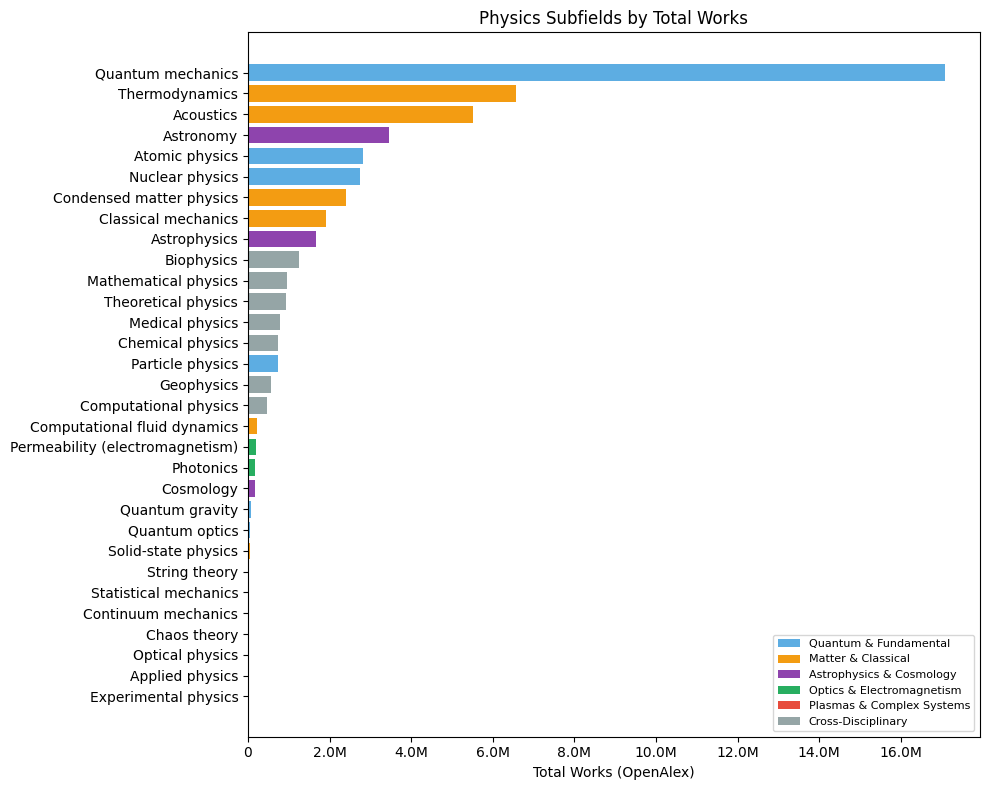

In [52]:
# --- Bar chart: Total works by subfield ---
df_plot = df_summary.sort_values("Total Works", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors = [GROUP_COLORS.get(g, "#bdc3c7") for g in df_plot["Group"]]

ax.barh(df_plot["Name"], df_plot["Total Works"], color=bar_colors)
ax.set_xlabel("Total Works (OpenAlex)")
ax.set_title("Physics Subfields by Total Works")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
))

ax.legend(
    handles=[Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()],
    loc="lower right", fontsize=8
)
plt.tight_layout()
plt.show()

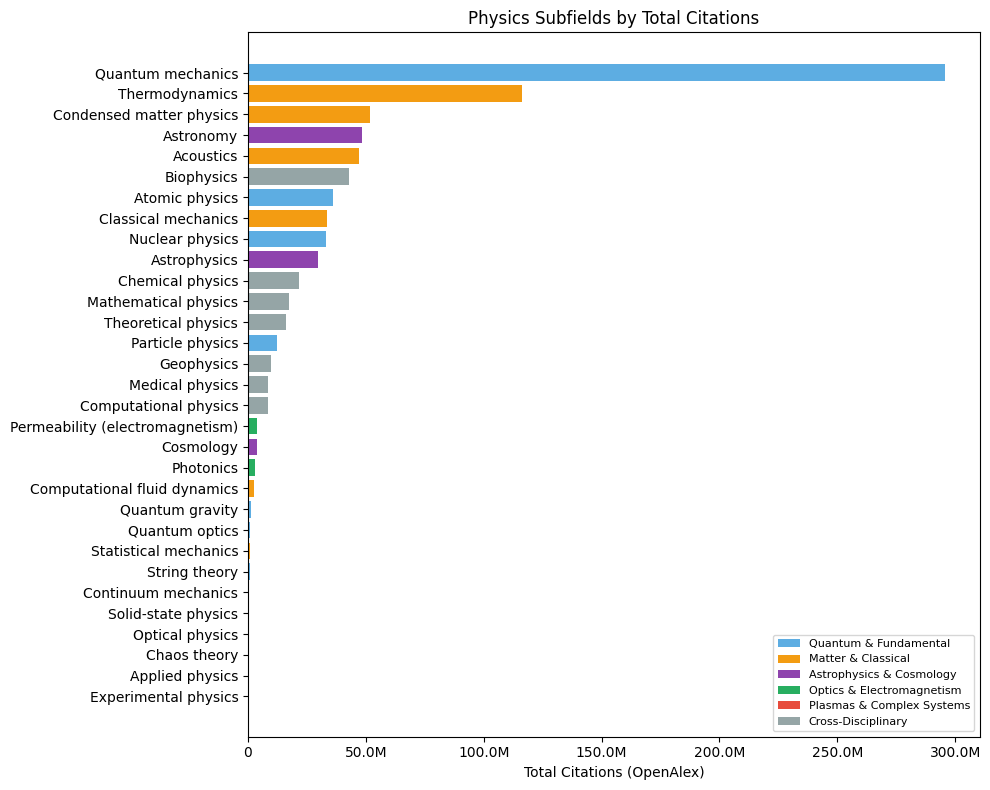

In [53]:
# --- Bar chart: Total citations by subfield ---
df_plot2 = df_summary.sort_values("Total Citations", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors2 = [GROUP_COLORS.get(g, "#bdc3c7") for g in df_plot2["Group"]]

ax.barh(df_plot2["Name"], df_plot2["Total Citations"], color=bar_colors2)
ax.set_xlabel("Total Citations (OpenAlex)")
ax.set_title("Physics Subfields by Total Citations")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
))

ax.legend(
    handles=[Patch(facecolor=c, label=g) for g, c in GROUP_COLORS.items()],
    loc="lower right", fontsize=8
)
plt.tight_layout()
plt.show()

### Works by decade â€” heatmap

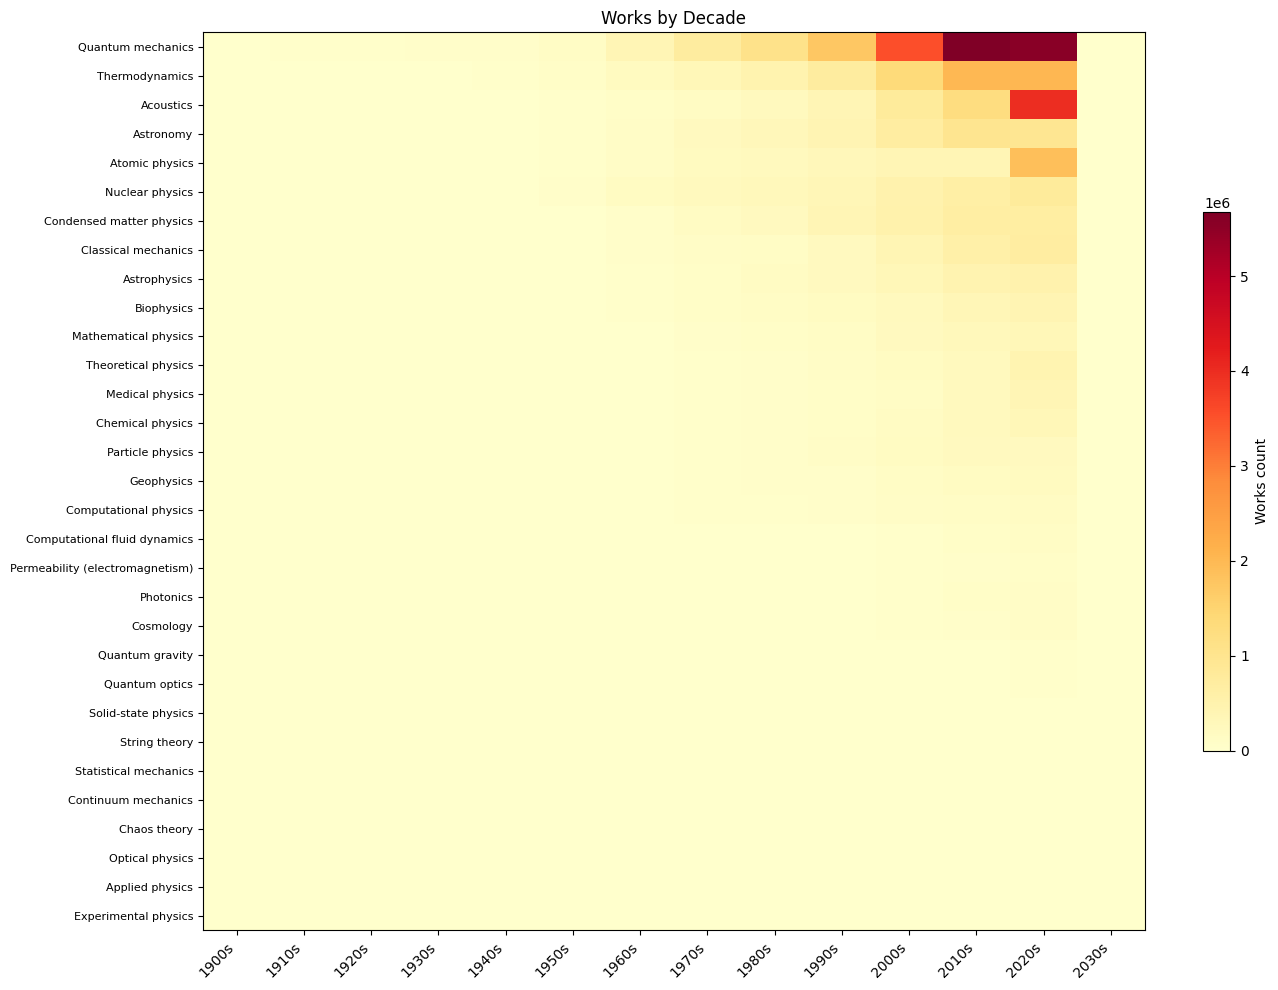

In [54]:
# Works by decade heatmap
all_decades = set()
for g in galaxies:
    for d in g.get("worksByDecade", []):
        all_decades.add(d["decade"])

decades_display = sorted(d for d in all_decades if d >= 1900)

decade_rows = []
for g in sorted(galaxies, key=lambda x: x.get("totalWorksCount", 0), reverse=True):
    decade_map = {d["decade"]: d["works_count"] for d in g.get("worksByDecade", [])}
    row = {"Name": g["name"]}
    for d in decades_display:
        row[str(d)] = decade_map.get(d, 0)
    decade_rows.append(row)

df_decades = pd.DataFrame(decade_rows).set_index("Name")

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(df_decades.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(len(decades_display)))
ax.set_xticklabels([f"{d}s" for d in decades_display], rotation=45, ha="right")
ax.set_yticks(range(len(df_decades)))
ax.set_yticklabels(df_decades.index, fontsize=8)
ax.set_title("Works by Decade")

plt.colorbar(im, ax=ax, label="Works count", shrink=0.6)
plt.tight_layout()
plt.show()

### Works by decade — stacked area (top 10 by total works)

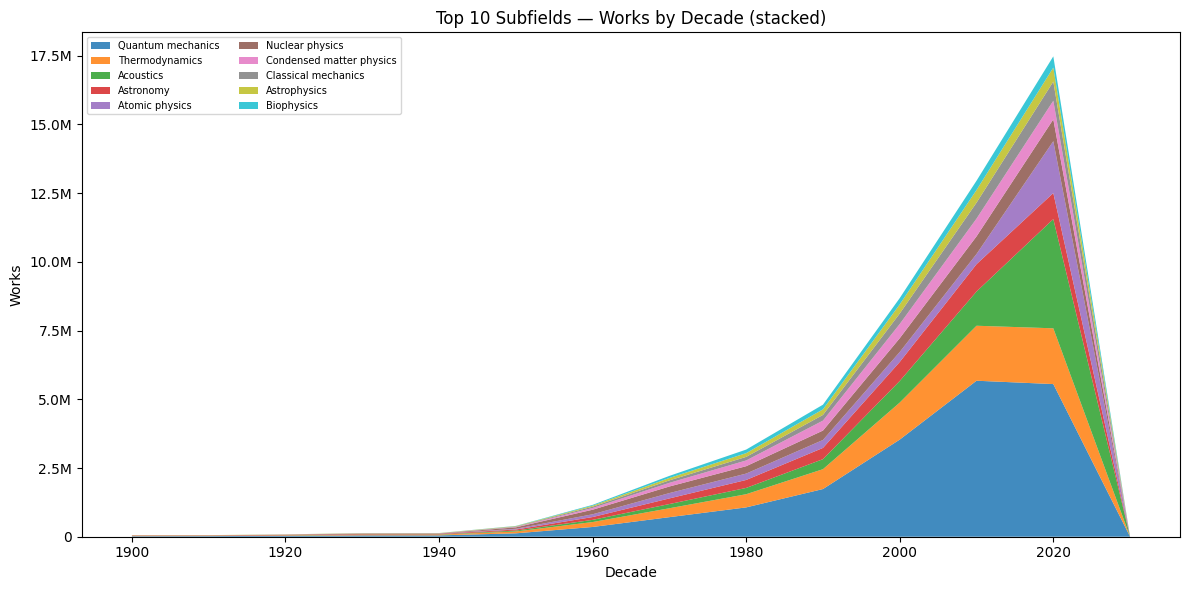

In [55]:
# Stacked area chart — top 10
top_names = df_summary.head(10)["Name"].tolist()
df_top = df_decades.loc[df_decades.index.isin(top_names)]

fig, ax = plt.subplots(figsize=(12, 6))
x = [int(c) for c in df_top.columns]

ax.stackplot(
    x, *[df_top.loc[name].values for name in df_top.index],
    labels=df_top.index, alpha=0.85
)
ax.set_xlabel("Decade")
ax.set_ylabel("Works")
ax.set_title("Top 10 Subfields — Works by Decade (stacked)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
))
ax.legend(loc="upper left", fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

### Oldest and most-cited papers

In [56]:
# Papers table
paper_rows = []
for g in sorted(galaxies, key=lambda x: x.get("firstPublicationYear") or 9999):
    oldest = g.get("oldestWork")
    mc = g.get("mostCitedWork")
    paper_rows.append({
        "Subfield": g["name"],
        "First Year": oldest.get("year") if oldest else None,
        "Oldest Paper": (oldest.get("title") or "?")[:60] if oldest else "n/a",
        "Top Cited Year": mc.get("year") if mc else None,
        "Citations": mc.get("citations", 0) if mc else 0,
        "Most-Cited Paper": (mc.get("title") or "?")[:60] if mc else "n/a",
    })

df_papers = pd.DataFrame(paper_rows)
df_papers.index += 1
df_papers.index.name = "#"

df_papers.style.format({"Citations": "{:,.0f}"}).bar(
    subset=["Citations"], color="#f9e79f"
).set_caption("Oldest and Most-Cited Papers per Subfield — sorted by first publication year")

,Subfield,First Year,Oldest Paper,Top Cited Year,Citations,Most-Cited Paper
#,,,,,,
1,Quantum mechanics,1019,"Savoirs savants, savoirs d’action et co-constructions au pri",1996,"205,948",Generalized Gradient Approximation Made Simple
2,Thermodynamics,1397,An Estimator for Torque and Draft Force Requirements of a Ne,1996,"205,948",Generalized Gradient Approximation Made Simple
3,Astrophysics,1400,Guiding Star,1998,"18,478",Observational Evidence from Supernovae for an Accelerating U
4,Astronomy,1400,Guiding Star,2001,"178,717",Analysis of Relative Gene Expression Data Using Real-Time Qu
5,Geophysics,1400,The Slab Boys,2000,"11,963",Negative Refraction Makes a Perfect Lens
6,Nuclear physics,1500,Development of a Compact and Sensitive Electrostatic Radon-2,2020,"801,217",Radiation Resistant Camera System for Monitoring Deuterium P
7,Classical mechanics,1500,Acceleration test method for GMR/TMR head instability,1994,"88,378",Projector augmented-wave method
8,Acoustics,1500,dummyRelationship between shelf sedimentation and climate ch,1976,"225,299",A Rapid and Sensitive Method for the Quantitation of Microgr
9,Condensed matter physics,1524,Pauli Iouii Nouocomensis Medici De Romanis piscibus libellus,1996,"205,948",Generalized Gradient Approximation Made Simple


### Top-cited paper per subfield

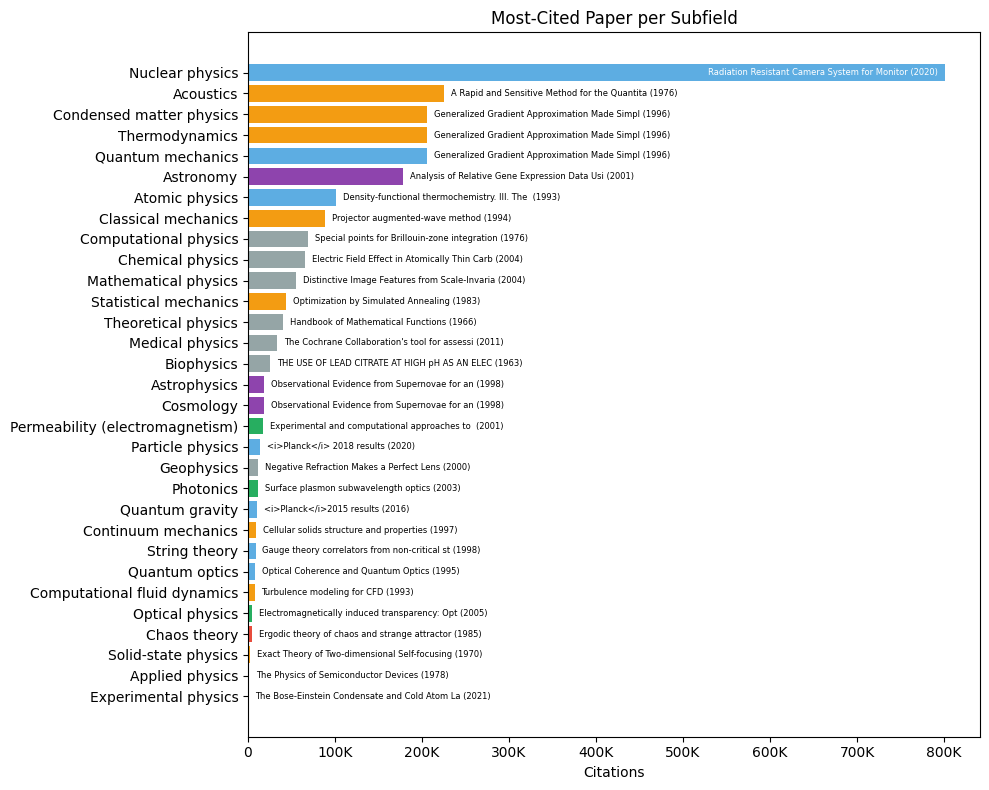

In [57]:
# Most-cited paper per subfield — bar chart with paper titles
mc_rows = []
for g in galaxies:
    mc = g.get("mostCitedWork")
    if mc and mc.get("citations"):
        mc_rows.append({
            "Subfield": g["name"],
            "Group": g["group"],
            "Citations": mc["citations"],
            "Title": (mc.get("title") or "?")[:45],
            "Year": mc.get("year"),
        })

df_mc = pd.DataFrame(mc_rows).sort_values("Citations", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
bar_colors3 = [GROUP_COLORS.get(g, "#bdc3c7") for g in df_mc["Group"]]
bars = ax.barh(df_mc["Subfield"], df_mc["Citations"], color=bar_colors3)

max_cit = df_mc["Citations"].max()
for bar, title, year in zip(bars, df_mc["Title"], df_mc["Year"]):
    label = f"{title} ({year})"
    if bar.get_width() > max_cit * 0.3:
        ax.text(bar.get_width() - max_cit * 0.01,
                bar.get_y() + bar.get_height() / 2,
                label, ha="right", va="center", fontsize=6, color="white")
    else:
        ax.text(bar.get_width() + max_cit * 0.01,
                bar.get_y() + bar.get_height() / 2,
                label, ha="left", va="center", fontsize=6)

ax.set_xlabel("Citations")
ax.set_title("Most-Cited Paper per Subfield")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: f"{x/1e3:.0f}K" if x >= 1e3 else f"{x:.0f}"
))
plt.tight_layout()
plt.show()

## 4. Local galaxies (papers you've already imported)
Scans only `data/` for `*_nodes.json` files and matches them to subfields above.  
Each file appears once — no duplicates from frontend or build directories.

In [58]:
# Only scan the canonical data directory to avoid duplicates
local_galaxies = []

if DATA_DIR.exists():
    for f in sorted(DATA_DIR.iterdir()):
        if not f.name.endswith("_nodes.json"):
            continue

        g_id = f.name.replace("_nodes.json", "")
        display_name = g_id.replace("_", " ").title()

        # Read node count from the JSON file
        try:
            nodes = json.loads(f.read_text(encoding="utf-8"))
            node_count = len(nodes) if isinstance(nodes, list) else 0
        except Exception as e:
            node_count = 0
            print(f"  [warn] Could not read {f.name}: {e}")

        # Read edge count
        edges_path = DATA_DIR / f"{g_id}_edges.json"
        edge_count = 0
        if edges_path.exists():
            try:
                edges = json.loads(edges_path.read_text(encoding="utf-8"))
                edge_count = len(edges) if isinstance(edges, list) else 0
            except Exception:
                pass

        meta_path = DATA_DIR / f"{g_id}_metadata.json"

        # Match to a fetched galaxy
        matched_galaxy = None
        for g in galaxies:
            gn = g["name"].lower()
            dn = display_name.lower()
            if gn == dn or gn in dn or dn in gn:
                matched_galaxy = g["name"]
                break

        local_galaxies.append({
            "File": f.name,
            "Display Name": display_name,
            "Nodes": node_count,
            "Edges": edge_count,
            "Has Metadata": meta_path.exists(),
            "Matched Subfield": matched_galaxy or "-",
        })

        # Merge into galaxy data for export
        if matched_galaxy:
            for g in galaxies:
                if g["name"] == matched_galaxy:
                    g["nodeCount"] = node_count
                    g["edgeCount"] = edge_count
                    g["hasPapers"] = True
                    g["nodesFile"] = f"{g_id}_nodes.json"
                    g["edgesFile"] = f"{g_id}_edges.json"
                    g["metadataFile"] = f"{g_id}_metadata.json"
                    break

if local_galaxies:
    df_local = pd.DataFrame(local_galaxies)
    df_local.index += 1
    df_local.index.name = "#"
    display(
        df_local.style.format({"Nodes": "{:,}", "Edges": "{:,}"}).bar(
            subset=["Nodes"], color="#aed6f1"
        ).bar(
            subset=["Edges"], color="#a9dfbf"
        ).set_caption(f"Local galaxy files in {DATA_DIR}")
    )
else:
    print(f"No *_nodes.json files found in {DATA_DIR}")

,File,Display Name,Nodes,Edges,Has Metadata,Matched Subfield
#,,,,,,
1,astrophysics_nodes.json,Astrophysics,"1,000","1,970",True,Astrophysics
2,classical_mechanics_nodes.json,Classical Mechanics,"1,000",291,True,Classical mechanics
3,condensed_matter_nodes.json,Condensed Matter,"1,994","9,000",True,Condensed matter physics
4,condensed_matter_physics_nodes.json,Condensed Matter Physics,"1,000","3,344",True,Condensed matter physics
5,optics_nodes.json,Optics,"1,000",4,True,Quantum optics
6,particle_physics_nodes.json,Particle Physics,"1,000","5,795",True,Particle physics


## 5. Export to universe.json (optional)
Set `EXPORT_JSON = True` in the configuration cell to enable.

In [59]:
if not EXPORT_JSON:
    print("Export disabled. Set EXPORT_JSON = True in the config cell to export.")
else:
    from build_universe_json import generate_universe_nodes, fetch_wikimedia_icon

    # Sort by first publication year for spiral layout
    galaxies.sort(key=lambda x: x.get("firstPublicationYear") or 2000)

    # Ensure all galaxies have required fields
    for g in galaxies:
        g.setdefault("nodeCount", 0)
        g.setdefault("edgeCount", 0)
        g.setdefault("hasPapers", False)
        g.setdefault("nodesFile", f"{g['id']}_nodes.json")
        g.setdefault("edgesFile", f"{g['id']}_edges.json")
        g.setdefault("metadataFile", f"{g['id']}_metadata.json")
        g.setdefault("totalCitations", g.get("cited_by_count", 0))
        g.setdefault("timeline_y", 0)

    # Fetch icons
    fe_dir = FRONTEND_DIR if COPY_TO_FRONTEND and os.path.exists(FRONTEND_DIR) else None
    if fe_dir:
        for g in galaxies:
            icon = fetch_wikimedia_icon(g["name"], fe_dir)
            if icon:
                g["iconPath"] = icon

    # Generate positioned nodes
    universe_nodes = generate_universe_nodes(galaxies, layout=LAYOUT)

    output_data = {
        "nodes": universe_nodes,
        "metadata": {
            "galaxyCount": len(universe_nodes),
            "generatedAt": time.strftime("%Y-%m-%d %H:%M:%S")
        }
    }

    os.makedirs(os.path.dirname(OUTPUT_PATH) or ".", exist_ok=True)
    with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
        json.dump(output_data, f, indent=2)
    print(f"Wrote {OUTPUT_PATH} ({len(universe_nodes)} galaxies)")

    if COPY_TO_FRONTEND and os.path.exists(FRONTEND_DIR):
        import shutil
        dest = os.path.join(FRONTEND_DIR, "universe.json")
        shutil.copy2(OUTPUT_PATH, dest)
        print(f"Copied to {dest}")

Export disabled. Set EXPORT_JSON = True in the config cell to export.
